In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# read dataset
df=pd.read_excel(r"D:\\workshop-2\\All Python\\python programming\\dataAnalysis\\ott_Report\\DataSet\\Netflix_AmazonPrime_10_Year_Dataset.xlsx")
# print data
print(df)

    Year      Platform  Total Content Added  Content Growth (%)  Hit Titles  \
0   2016       Netflix                 1843                  16        1190   
1   2016  Amazon Prime                 3102                  12        1815   
2   2017       Netflix                 2018                  14        1265   
3   2017  Amazon Prime                 1863                   8        1221   
4   2018       Netflix                 2715                   8        1937   
5   2018  Amazon Prime                 1415                  15        1016   
6   2019       Netflix                 1272                   8         906   
7   2019  Amazon Prime                 2104                   9        1273   
8   2020       Netflix                 2878                  13        1647   
9   2020  Amazon Prime                 2112                   6        1513   
10  2021       Netflix                 2816                  15        1961   
11  2021  Amazon Prime                 1230         

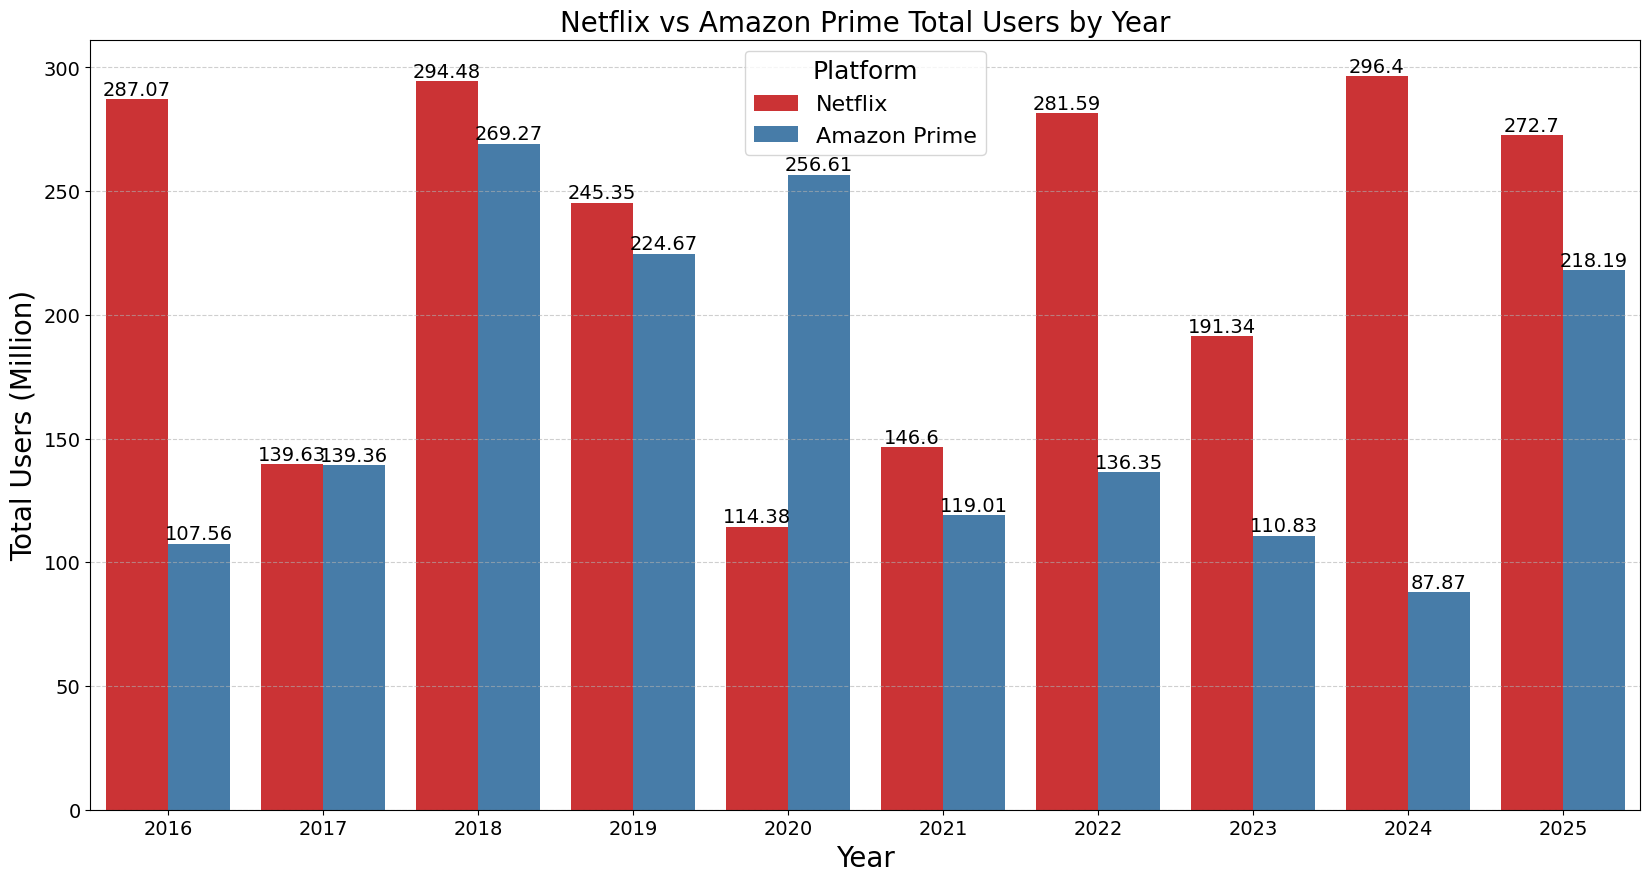

In [5]:
# grouped bar chart(Total Users (Million))
plt.figure(figsize=(20,10))
ax=sns.barplot(
    x="Year", 
    y="Total Users (Million)", 
    hue="Platform", 
    data=df,
    dodge=True,        # ensures bars are side by side
    palette="Set1"     # optional, just makes colors nicer
)
for container in ax.containers:
    ax.bar_label(container, fontsize=14)
    
plt.title("Netflix vs Amazon Prime Total Users by Year", fontsize=20)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Total Users (Million)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(title="Platform", fontsize=16, title_fontsize=18)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

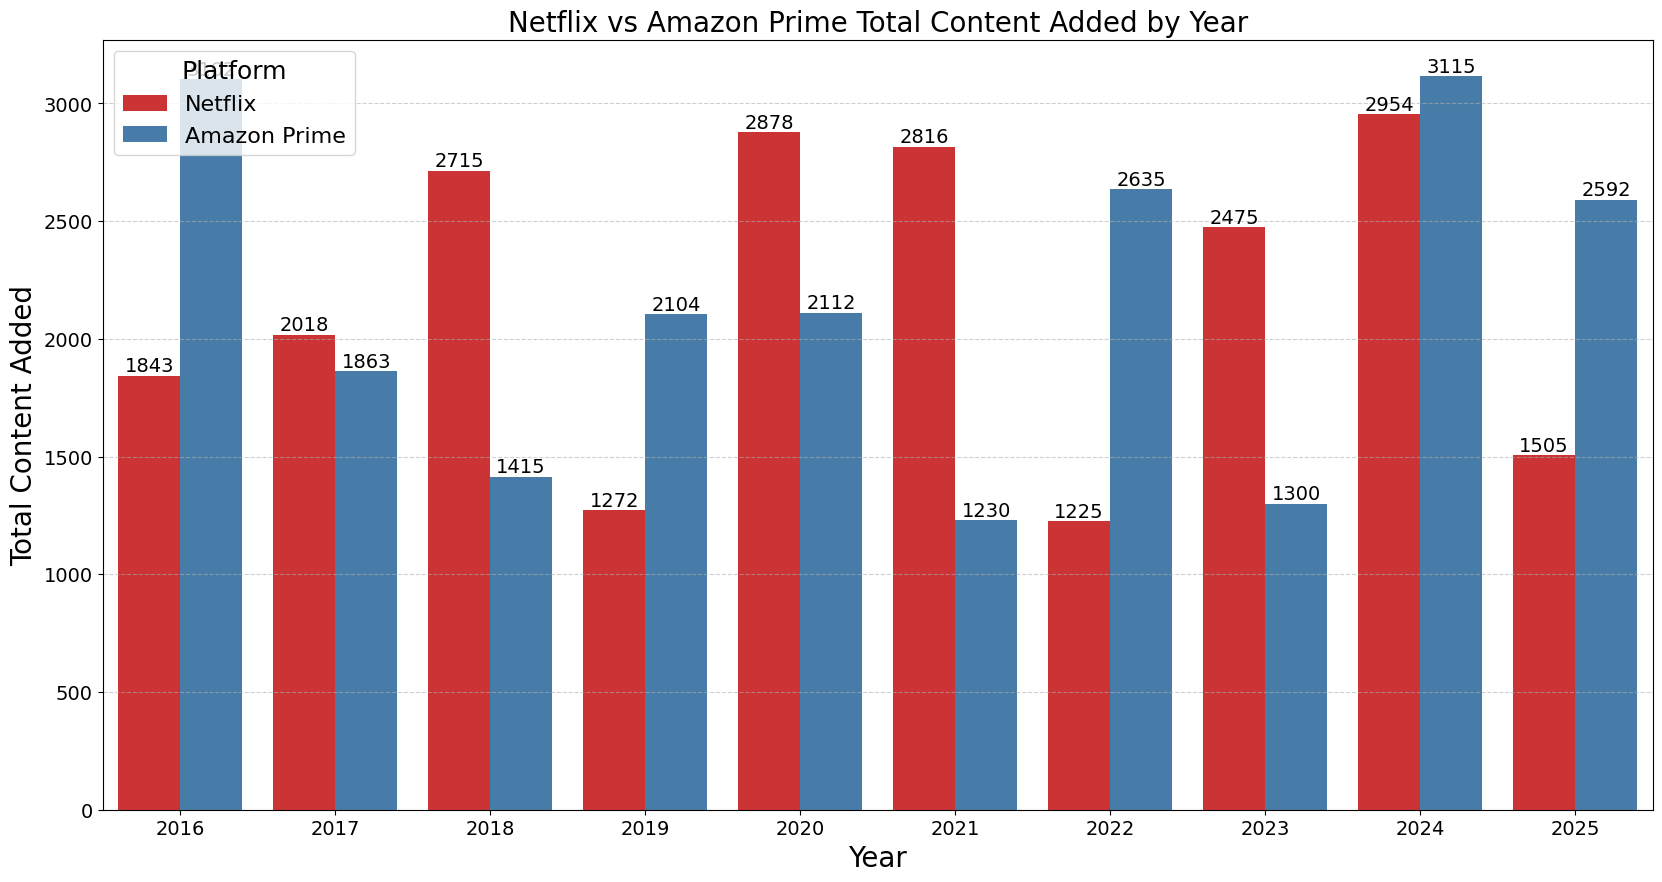

In [6]:
# grouped bar chart(Total Content Added)
plt.figure(figsize=(20,10))
ax=sns.barplot(
    x="Year", 
    y="Total Content Added", 
    hue="Platform", 
    data=df,
    dodge=True,           # keeps bars side by side
    palette="Set1"        # optional, makes it more colorful
)
for container in ax.containers:
    ax.bar_label(container, fontsize=14)
    
plt.title("Netflix vs Amazon Prime Total Content Added by Year", fontsize=20)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Total Content Added", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(title="Platform", fontsize=16, title_fontsize=18)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

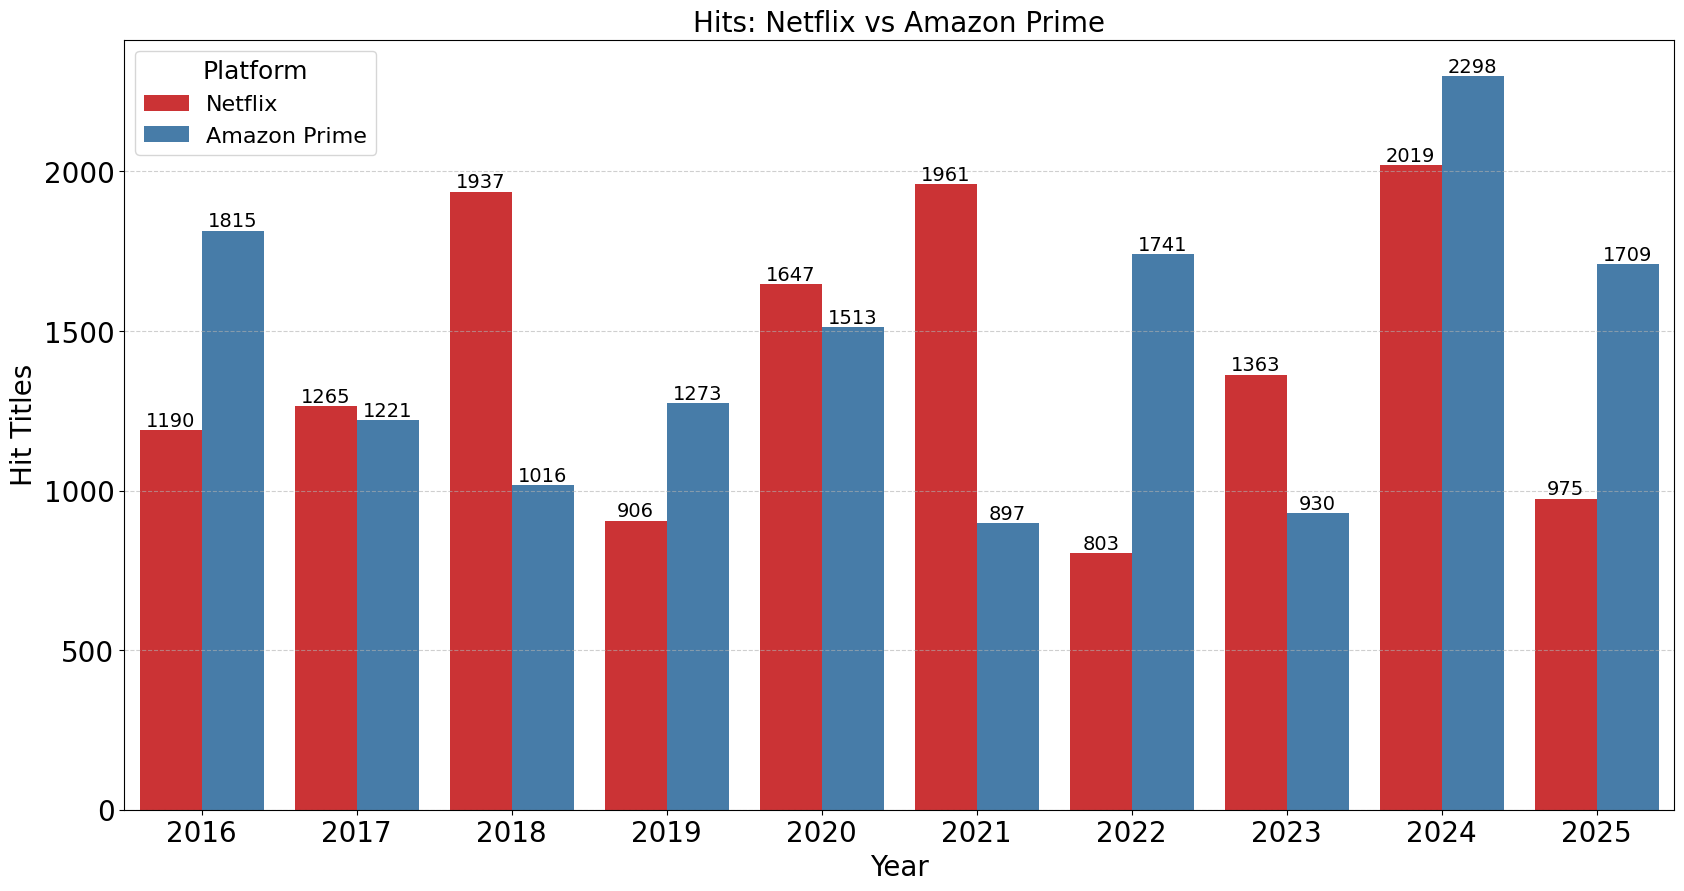

In [7]:
plt.figure(figsize=(20,10))

ax = sns.barplot(
    data=df,
    x="Year",
    y="Hit Titles",
    hue="Platform",
    dodge=True,
    palette="Set1"
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fontsize=14)

plt.title("Hits: Netflix vs Amazon Prime", fontsize=20)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Hit Titles", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(title="Platform", fontsize=16, title_fontsize=18)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

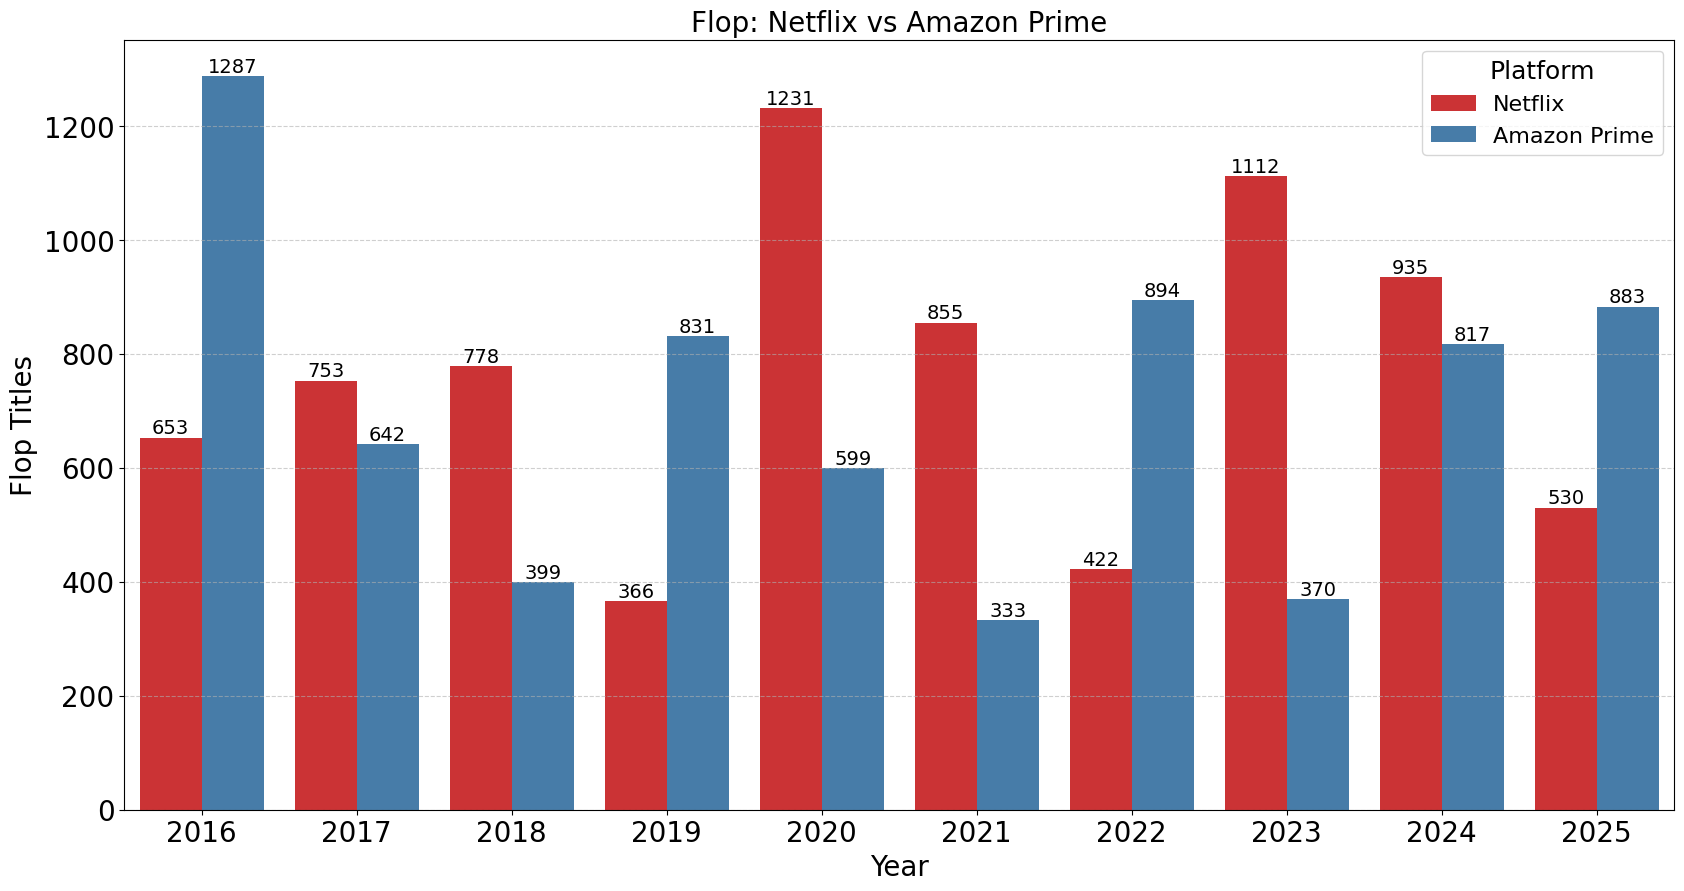

In [8]:
plt.figure(figsize=(20,10))

ax = sns.barplot(
    data=df,
    x="Year",
    y="Flop Titles",
    hue="Platform",
    dodge=True,
    palette="Set1"
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fontsize=14)

plt.title("Flop: Netflix vs Amazon Prime", fontsize=20)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Flop Titles", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(title="Platform", fontsize=16, title_fontsize=18)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [9]:
# Group by Year & Platform
hits_df = df.groupby(["Year","Platform"])["Hit Titles"].sum().reset_index()
# Calculate total hits per year
total_hits = hits_df.groupby("Year")["Hit Titles"].transform("sum")
# Calculate percentage
hits_df["Hit %"] = (hits_df["Hit Titles"] / total_hits) * 100

pivot_df = hits_df.pivot(index="Year",
                         columns="Platform",
                         values="Hit %")

<Figure size 2000x1000 with 0 Axes>

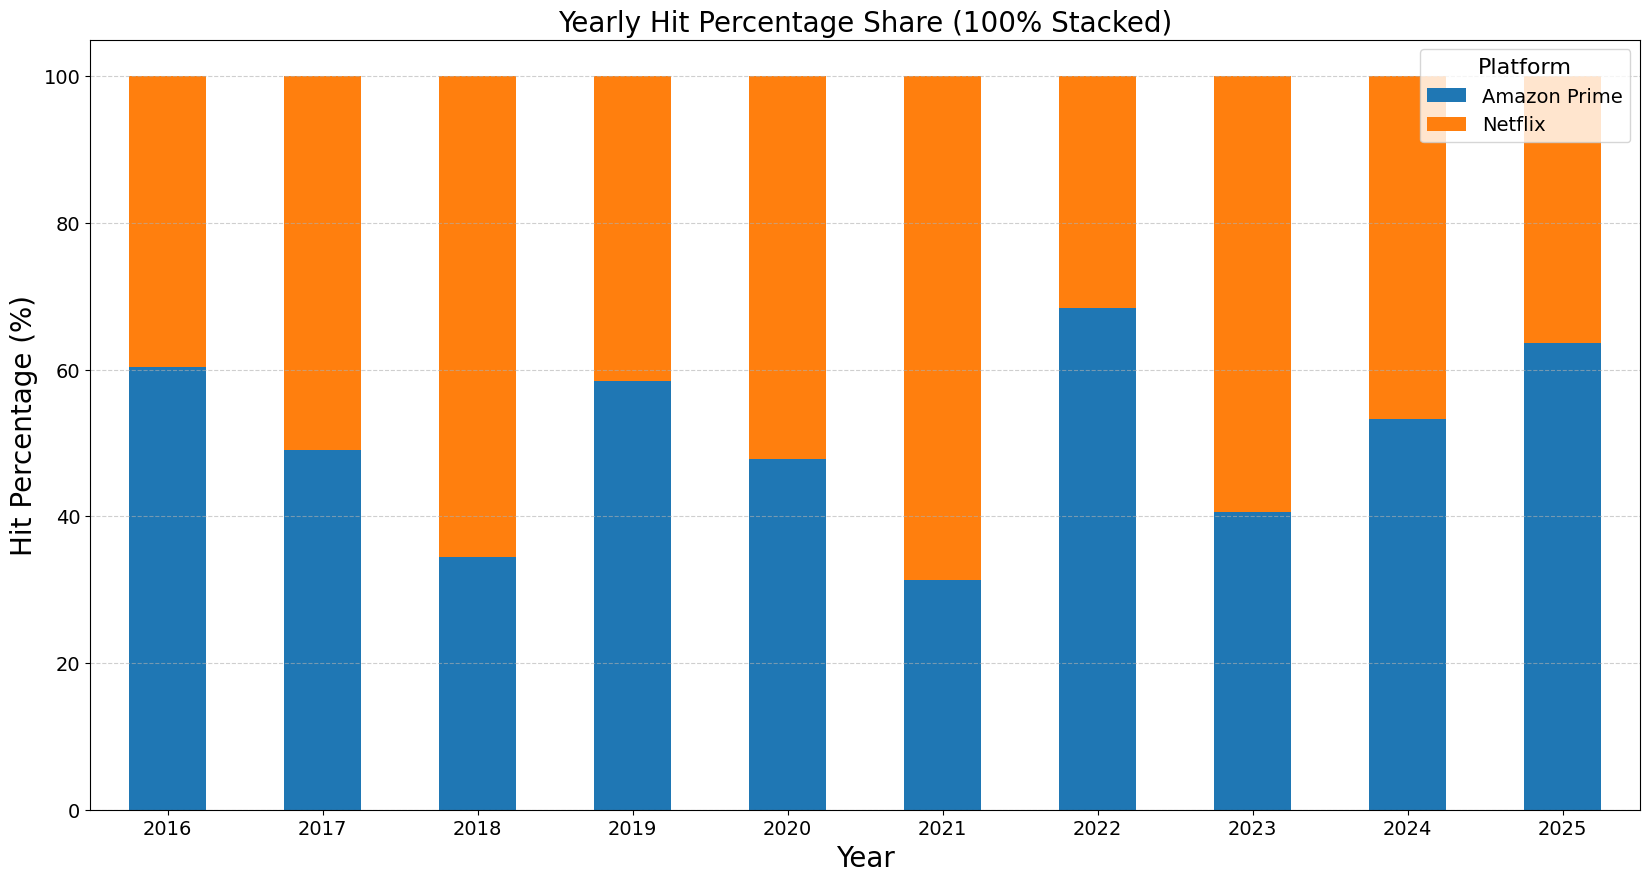

In [10]:
#graph 
plt.figure(figsize=(20,10))

pivot_df.plot(kind="bar",
              stacked=True,
              figsize=(20,10))

plt.title("Yearly Hit Percentage Share (100% Stacked)", fontsize=20)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Hit Percentage (%)", fontsize=20)
plt.xticks(rotation=0, fontsize=14)
plt.yticks(fontsize=14)
plt.legend(title="Platform", fontsize=14, title_fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

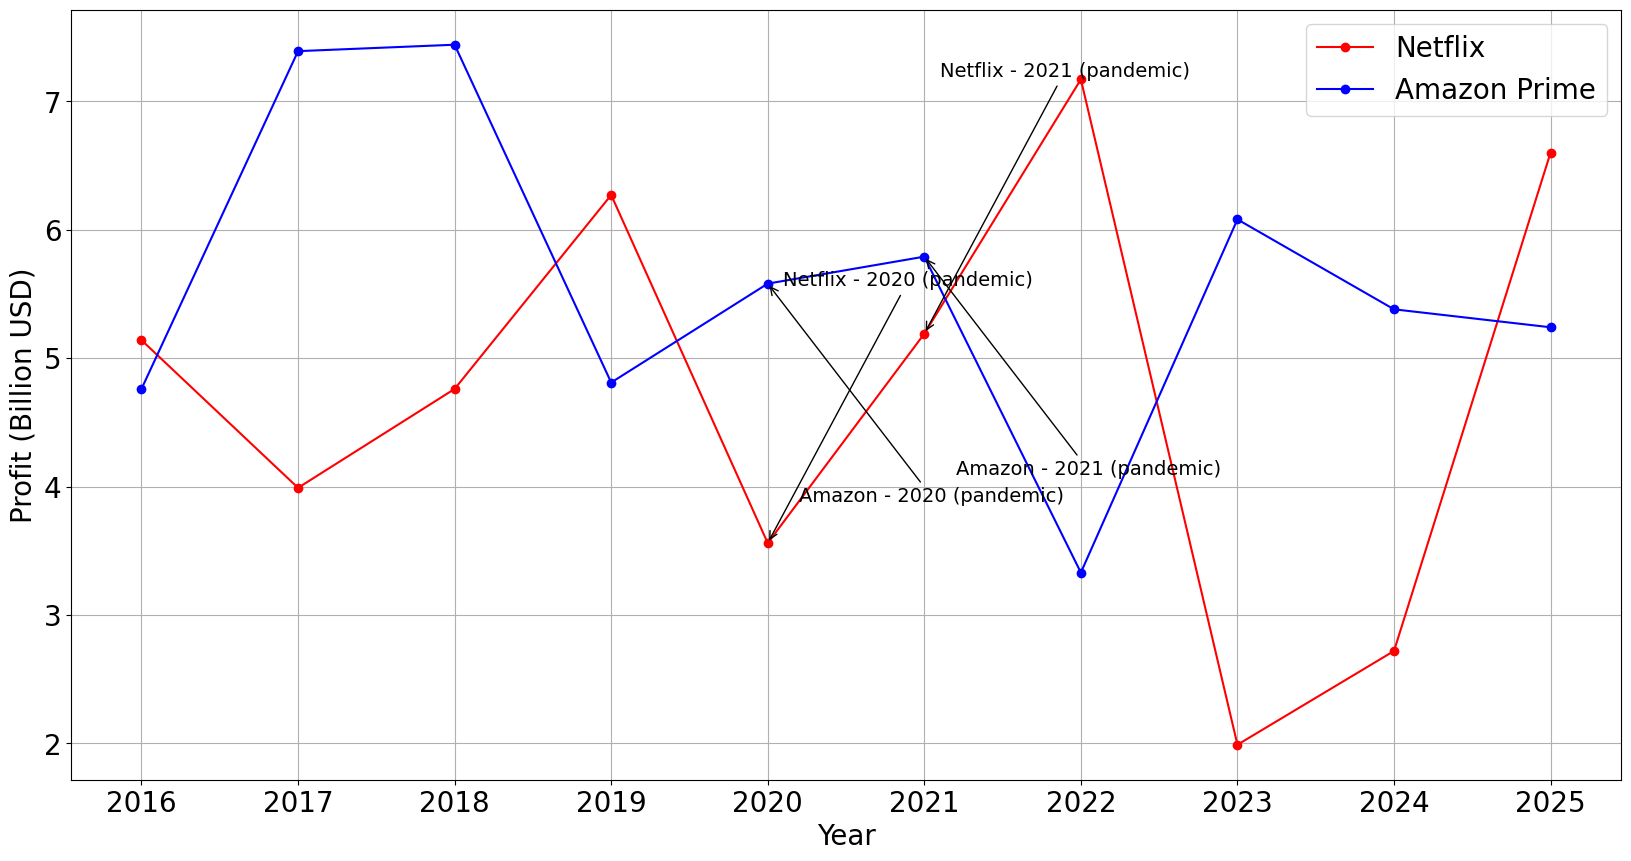

In [11]:
plt.figure(figsize=(20,10))

platforms = ["Netflix", "Amazon Prime"]
colors = {"Netflix": "red", "Amazon Prime": "blue"}
annotations = {("Netflix", 2020): "Netflix - 2020 (pandemic)",
               ("Netflix", 2021): "Netflix - 2021 (pandemic)",
               ("Amazon Prime", 2020): "Amazon - 2020 (pandemic)",
               ("Amazon Prime", 2021): "Amazon - 2021 (pandemic)"}

for platform in platforms:
    data = df[df["Platform"] == platform]
    plt.plot(data["Year"], data["Profit (Billion USD)"], 
             marker="o", label=platform, color=colors[platform])
    
    # Annotate points if in annotations
    for year in data["Year"]:
        key = (platform, year)
        if key in annotations:
            value = data.loc[data["Year"] == year, "Profit (Billion USD)"].iloc[0]
            offset = 2 if platform == "Netflix" else -1.7  # move text above/below
            plt.annotate(annotations[key],
                         xy=(year, value),
                         xytext=(year + (0.1 if platform=="Netflix" else 0.2), value + offset),
                         arrowprops=dict(arrowstyle="->"),
                         fontsize=14)

plt.xlabel("Year", fontsize=20)
plt.ylabel("Profit (Billion USD)", fontsize=20)
plt.xticks(df["Year"].unique(), fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.show()

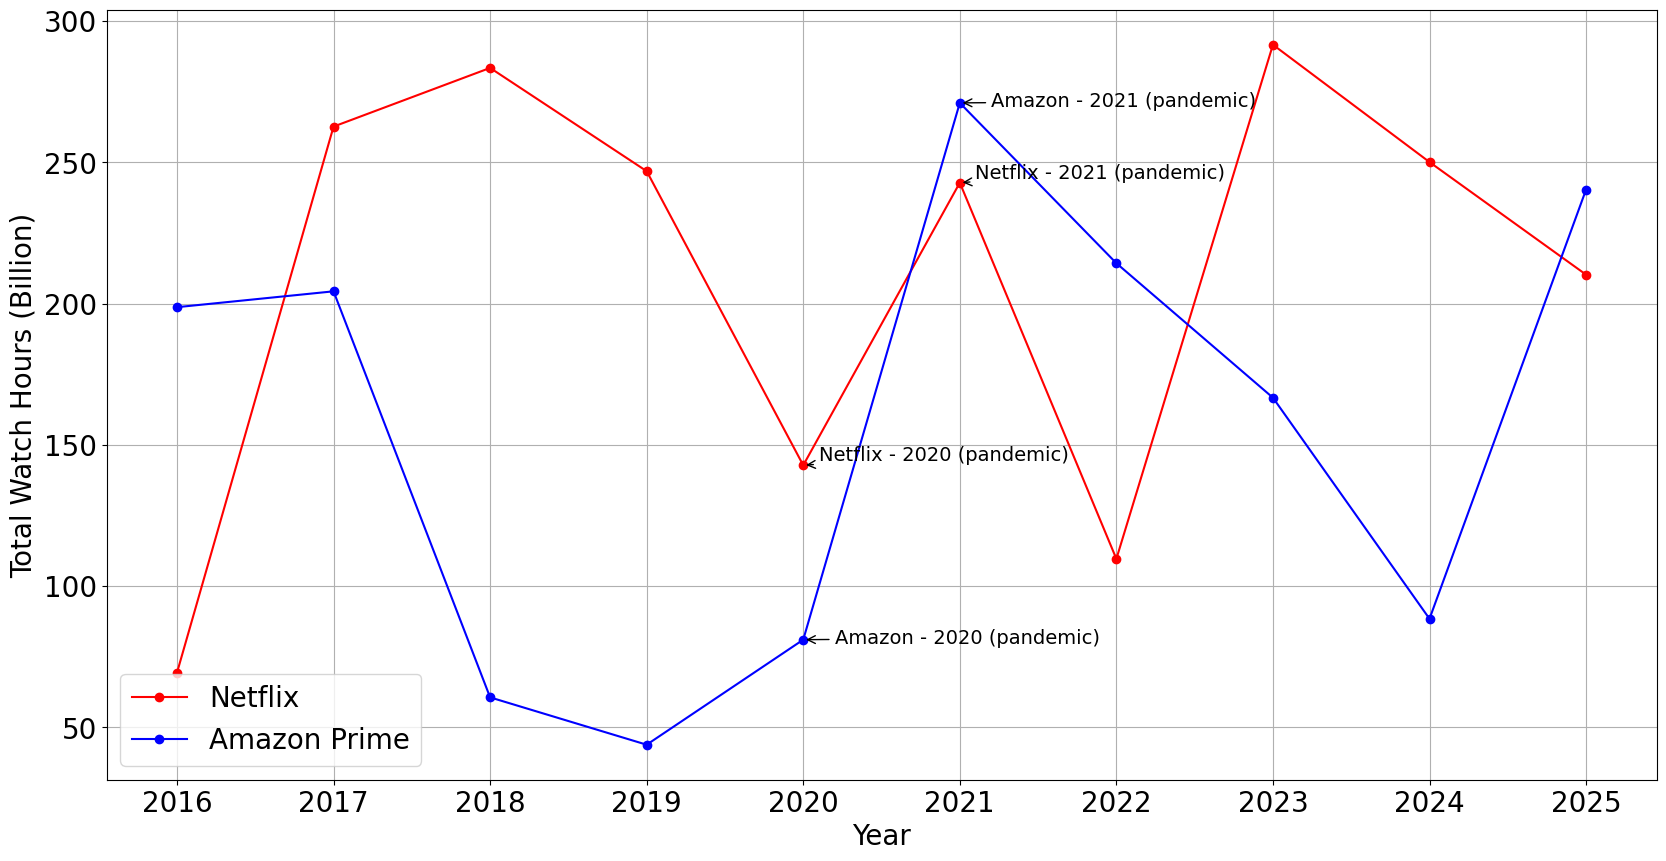

In [12]:
plt.figure(figsize=(20,10))

platforms = ["Netflix", "Amazon Prime"]
colors = {"Netflix": "red", "Amazon Prime": "blue"}
annotations = {("Netflix", 2020): "Netflix - 2020 (pandemic)",
               ("Netflix", 2021): "Netflix - 2021 (pandemic)",
               ("Amazon Prime", 2020): "Amazon - 2020 (pandemic)",
               ("Amazon Prime", 2021): "Amazon - 2021 (pandemic)"}

for platform in platforms:
    data = df[df["Platform"] == platform]
    plt.plot(data["Year"], data["Total Watch Hours (Billion)"], 
             marker="o", label=platform, color=colors[platform])
    
    # Annotate points if in annotations
    for year in data["Year"]:
        key = (platform, year)
        if key in annotations:
            value = data.loc[data["Year"] == year, "Total Watch Hours (Billion)"].iloc[0]
            offset = 1.5 if platform == "Netflix" else -1.5  # move text above/below
            plt.annotate(annotations[key],
                         xy=(year, value),
                         xytext=(year + (0.1 if platform=="Netflix" else 0.2), value + offset),
                         arrowprops=dict(arrowstyle="->"),
                         fontsize=14)

plt.xlabel("Year", fontsize=20)
plt.ylabel("Total Watch Hours (Billion)", fontsize=20)
plt.xticks(df["Year"].unique(), fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.show()

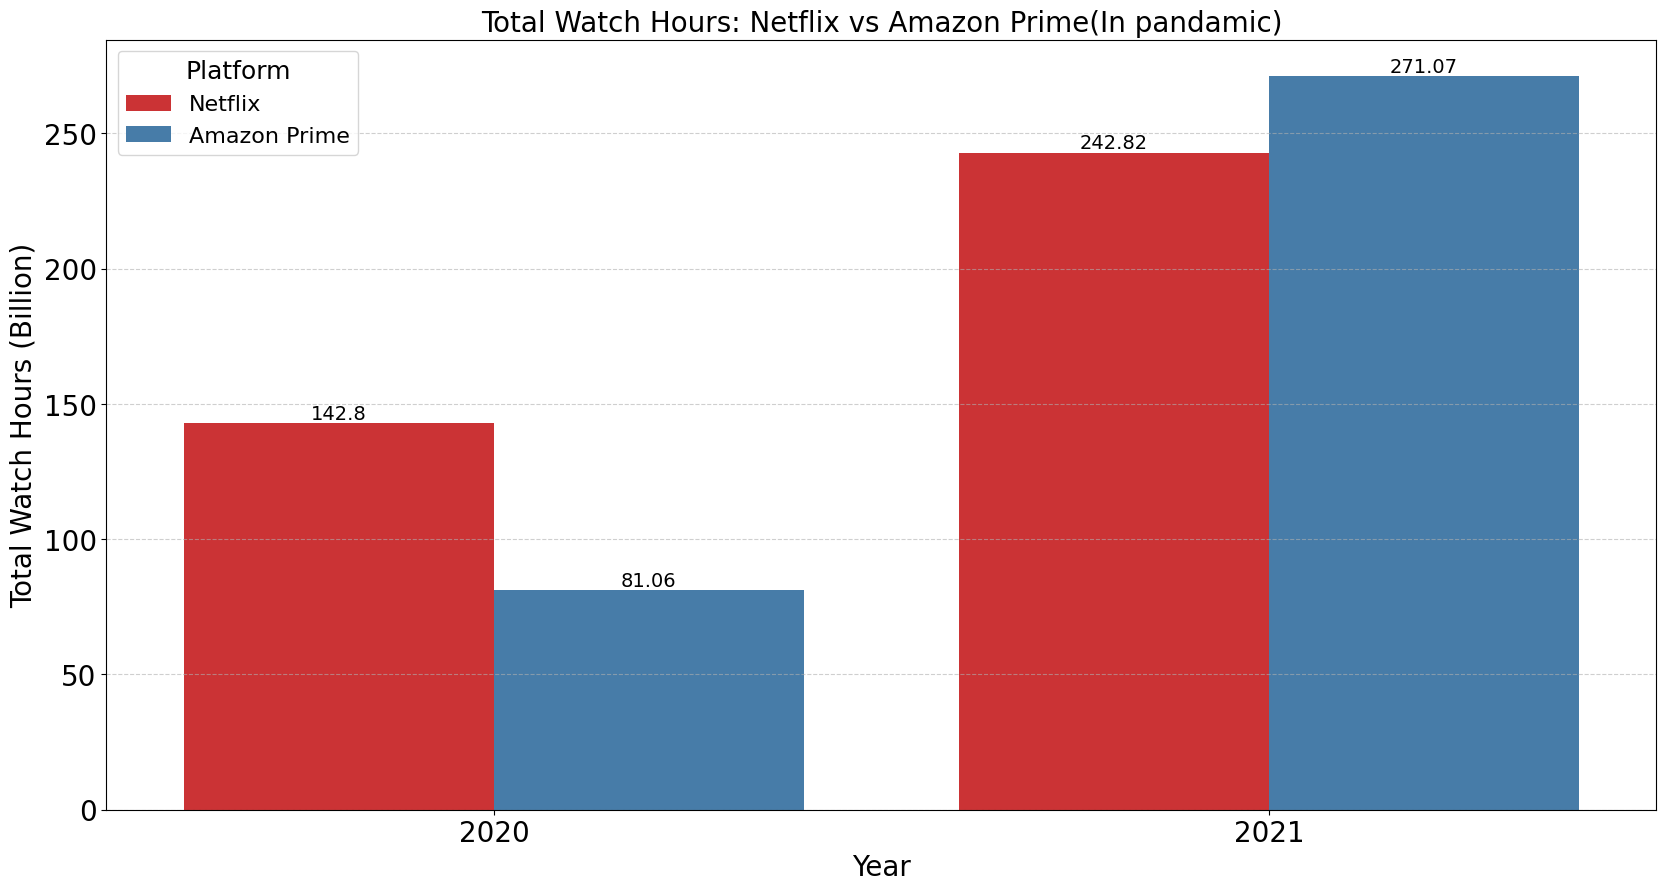

In [20]:
plt.figure(figsize=(20,10))
filtered_df = df[df["Year"].isin([2020, 2021])]
ax = sns.barplot(
    data=filtered_df,
    x="Year",
    y="Total Watch Hours (Billion)",
    hue="Platform",
    dodge=True,
    palette="Set1"
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fontsize=14)

plt.title("Total Watch Hours: Netflix vs Amazon Prime(In pandamic)", fontsize=20)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Total Watch Hours (Billion)", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(title="Platform", fontsize=16, title_fontsize=18)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()